# Normal toy example using SBI

In [21]:
import torch
import numpy as np
import pandas as pd
from torch.distributions import Distribution, Uniform, constraints
from sbi.inference import NPE_C, simulate_for_sbi
from sbi.neural_nets import posterior_nn
from sbi.neural_nets.embedding_nets import FCEmbedding
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)
from sbi.utils.user_input_checks import MultipleIndependent
from scipy.stats import norm, uniform
from sbi.analysis import plot_summary
from sbi.diagnostics import run_sbc, check_sbc, run_tarp, check_tarp
from sbi.analysis.plot import sbc_rank_plot
from sbi.analysis import plot_tarp
import tarp
import matplotlib.pyplot as plt
import seaborn as sns


torch_device = "cpu"
torch.set_default_device(torch_device)

## Model

**Prior:**
-  $\mu \sim \text{Uniform}[0, 10]$
-  $n \sim \text{Discrete Uniform}[10, 200]$

**Simulator:**
-  $x_{1:n} \sim N(\mu, 1)$
-  $s_1 = (\overline{x}, n)$
-  $s_2 = (\overline{x}, \overline{x^2}, n)$

In [4]:
class DiscreteUniform(Distribution):
    arg_constraints = {'low': constraints.real, 'high': constraints.real}

    def __init__(self, low, high, validate_args=None):
        self.low = torch.as_tensor(low, dtype=torch.float32)
        self.high = torch.as_tensor(high, dtype=torch.float32)
        self._num_categories = (self.high - self.low) + 1
        
        batch_shape = self.low.size()
        super().__init__(batch_shape=batch_shape, validate_args=validate_args)

    def sample(self, sample_shape=torch.Size()):
        low_int = int(self.low.min().item())
        high_int = int(self.high.max().item()) + 1
        expanded_shape = sample_shape + self.batch_shape
        samples = torch.randint(low_int, high_int, expanded_shape)
        return samples.float()

    def log_prob(self, value):
        log_p = -torch.log(self._num_categories)
        in_bounds = (value >= self.low) & (value <= self.high)
        return torch.where(in_bounds, log_p, torch.tensor(float('-inf')))
    
    @property
    def support(self):
        return constraints.interval(self.low, self.high)

    @property
    def mean(self):
        return (self.high + self.low) / 2.0

    @property
    def variance(self):
        n = self._num_categories
        return (n**2 - 1) / 12.0
    
    @property
    def stddev(self):
        return torch.sqrt(self.variance)

In [5]:
prior_mu = Uniform(low=torch.tensor([0.0]), high=torch.tensor([10.0]))
prior_n = DiscreteUniform(low=torch.tensor([10.0]), high=torch.tensor([200.0]))

prior_torch = MultipleIndependent(
    dists=[prior_mu, prior_n],
    validate_args=False,
    device=torch_device
)

In [6]:
def simulator_torch_1(theta):
    x = torch.randn(theta[1].int(), device=torch_device) + theta[0]
    s1 = torch.tensor([torch.mean(x), theta[1]], device=torch_device)
    return s1

In [7]:
def simulator_torch_2(theta):
    x = torch.randn(theta[1].int(), device=torch_device) + theta[0]
    s2 = torch.tensor([torch.mean(x), torch.mean(x**2), theta[1]], device=torch_device)
    return s2

## NPE-C

In [8]:
simulation_budget = 50000
num_posterior_samples=1000
seed = 1

In [9]:
simulator = simulator_torch_2

prior, num_parameters, prior_returns_numpy = process_prior(prior_torch)
simulator = process_simulator(simulator, prior, prior_returns_numpy)
check_sbi_inputs(simulator, prior)

learning_rate = 0.0005  # default value

torch.manual_seed(seed)
np.random.seed(seed)

theta, x = simulate_for_sbi(
    simulator=simulator, proposal=prior, num_simulations=simulation_budget
)

100%|██████████| 50000/50000 [00:02<00:00, 17960.46it/s]


In [10]:
x_1 = x[:, [0, 2]]
x_2 = x
x_1, x_2

(tensor([[1.0421e-01, 1.7000e+01],
         [6.6288e-01, 3.7000e+01],
         [2.2719e+00, 1.8300e+02],
         ...,
         [5.2001e-01, 1.9600e+02],
         [7.2511e+00, 6.4000e+01],
         [2.6597e+00, 6.9000e+01]]),
 tensor([[1.0421e-01, 7.4285e-01, 1.7000e+01],
         [6.6288e-01, 1.6852e+00, 3.7000e+01],
         [2.2719e+00, 6.2497e+00, 1.8300e+02],
         ...,
         [5.2001e-01, 1.2251e+00, 1.9600e+02],
         [7.2511e+00, 5.3413e+01, 6.4000e+01],
         [2.6597e+00, 7.9910e+00, 6.9000e+01]]))

In [11]:
def run_npe(prior, theta, x, seed=1, num_epochs=500):
    torch.manual_seed(seed)
    np.random.seed(seed)
    learning_rate = 0.0005  # default value

    inference = NPE_C(prior=prior, density_estimator="nsf", device=torch_device)

    density_estimator = inference.append_simulations(theta, x).train(
        max_num_epochs=num_epochs, 
        learning_rate=learning_rate,
        stop_after_epochs=20
    )

    fig, axes = plot_summary(
        inference, 
        tags=["training_loss", "validation_loss"], 
        figsize=(8, 4)
    )
    plt.title("Training and Validation Loss")
    plt.show()

    return inference.build_posterior(density_estimator)

**Simulator 1**

 Training neural network. Epochs trained: 76

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\u2008181\likelihood-free\python\normal_toy\sbi-logs\NPE_C\2026-03-24T16_09_39.724063' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


 Neural network successfully converged after 77 epochs.

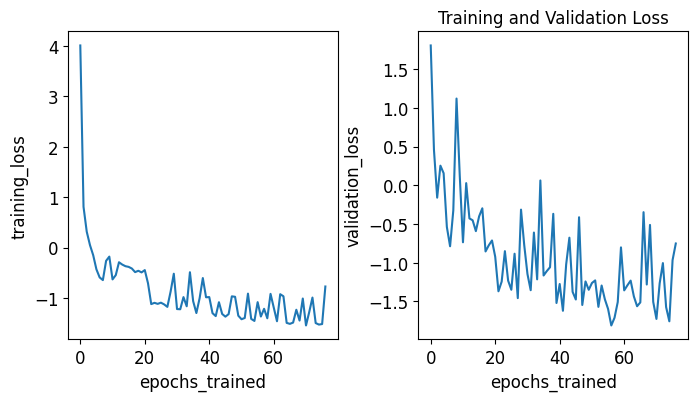

In [12]:
posterior_1 = run_npe(prior, theta, x_1)

**Simulator 2**

 Training neural network. Epochs trained: 121

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\u2008181\likelihood-free\python\normal_toy\sbi-logs\NPE_C\2026-03-24T16_18_56.699687' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


 Neural network successfully converged after 122 epochs.

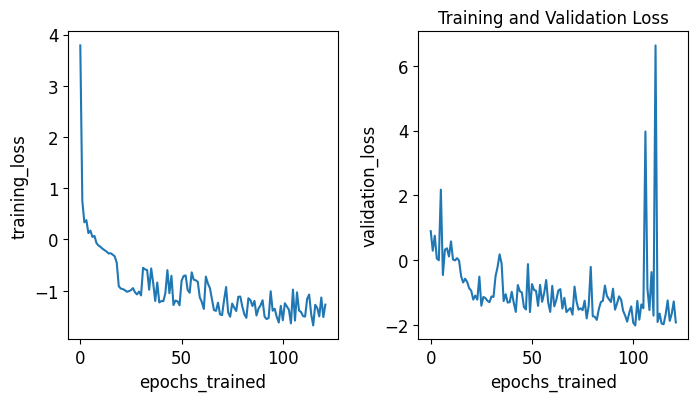

In [13]:
posterior_2 = run_npe(prior, theta, x_2)

If the true values are:
-  $\mu = 6.0$,
-  $n = 75$.

The observed summary statistics are shown below as

In [14]:
torch.manual_seed(1)
np.random.seed(1)
true_theta = torch.tensor([6.0, 75.0], device=torch_device)
x_o_2 = simulator_torch_2(true_theta)
x_o_1 = x_o_2[[0, 2]]
true_theta, x_o_1, x_o_2

(tensor([ 6., 75.]),
 tensor([ 5.9354, 75.0000]),
 tensor([ 5.9354, 36.0564, 75.0000]))

Plug in observed data to get the posterior.

In [16]:
theta_trained1 = posterior_1.set_default_x(x_o_1).sample((num_posterior_samples,), x=x_o_1)
theta_trained1 = theta_trained1.reshape((num_posterior_samples, 2))
theta_trained1_numpy = theta_trained1.cpu().numpy()

theta_trained2 = posterior_2.set_default_x(x_o_2).sample((num_posterior_samples,), x=x_o_2)
theta_trained2 = theta_trained2.reshape((num_posterior_samples, 2))
theta_trained2_numpy = theta_trained2.cpu().numpy()

1098it [00:00, 29851.15it/s]            
100%|██████████| 1000/1000 [00:00<00:00, 50727.53it/s]


**True posterior by the truncated normal distribution**

In [18]:
prior_a = 0.0
prior_b = 10.0
theta_grid = np.linspace(0, 10, 1000)
x_o_1_numpy = x_o_1.cpu().numpy()

prior_d = uniform.pdf(theta_grid, loc=prior_a, scale=(prior_b - prior_a))

likelihood = norm.pdf(x_o_1_numpy[0], loc=theta_grid, scale=1/np.sqrt(x_o_1_numpy[1]))

unnormalized_posterior = likelihood * prior_d
d_theta = theta_grid[1] - theta_grid[0]
posterior = unnormalized_posterior / (np.sum(unnormalized_posterior) * d_theta)

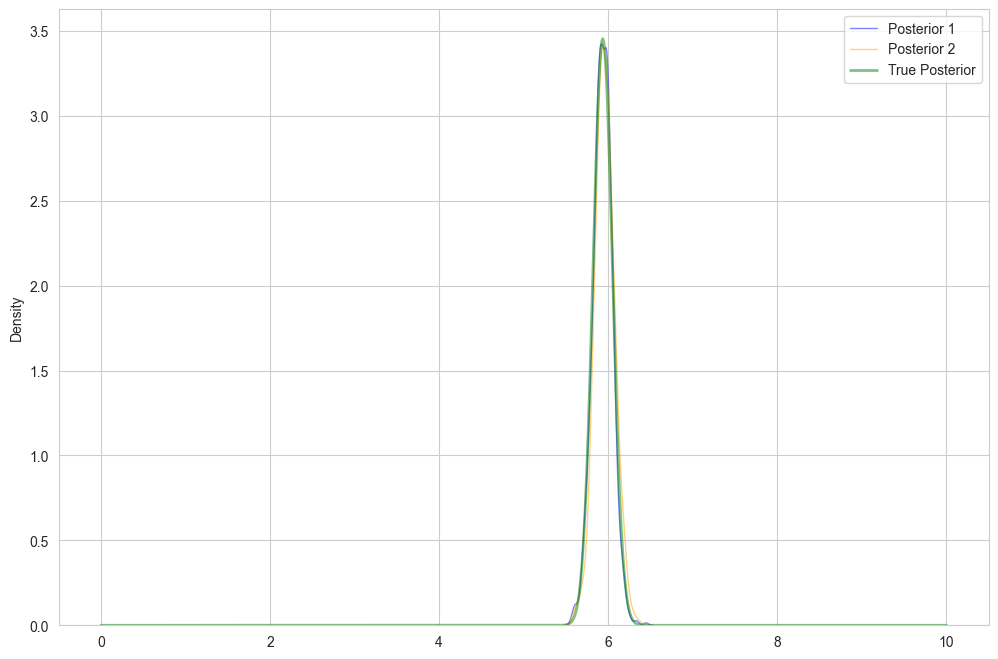

In [19]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained1_numpy[:, 0], label='Posterior 1', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained2_numpy[:, 0], label='Posterior 2', color='orange', linewidth=1, alpha=0.5)
plt.plot(theta_grid, posterior, label='True Posterior', color='green', linewidth=2, alpha=0.5)
plt.legend()
plt.show()

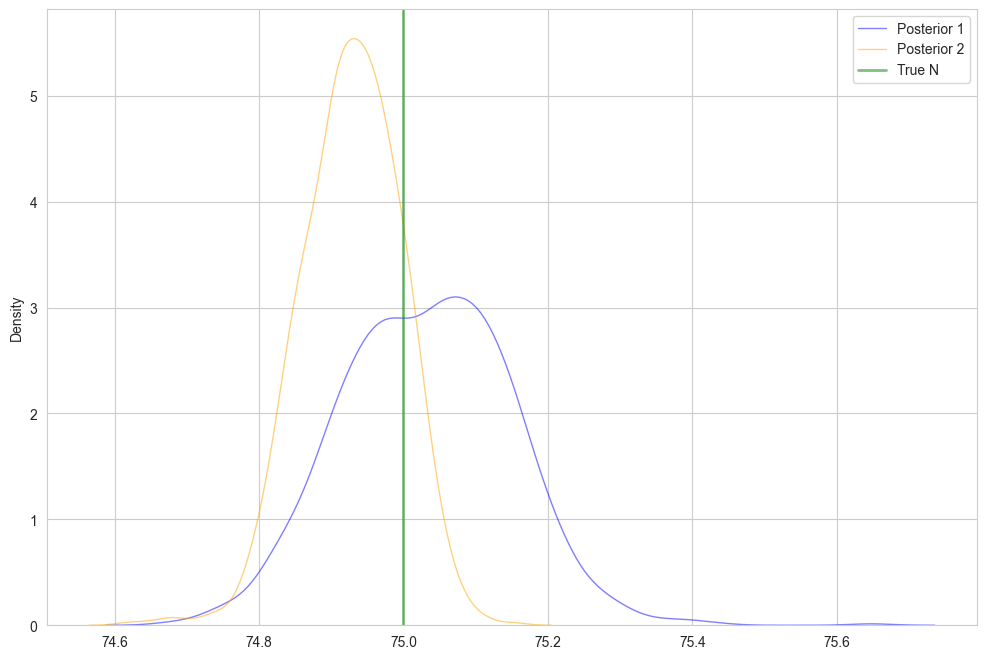

In [20]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained1_numpy[:, 1], label='Posterior 1', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained2_numpy[:, 1], label='Posterior 2', color='orange', linewidth=1, alpha=0.5)
plt.axvline(x=true_theta[1], label='True N', color='green', linewidth=2, alpha=0.5)
plt.legend()
plt.show()

### Pair plots for $\mu$ and $n$.

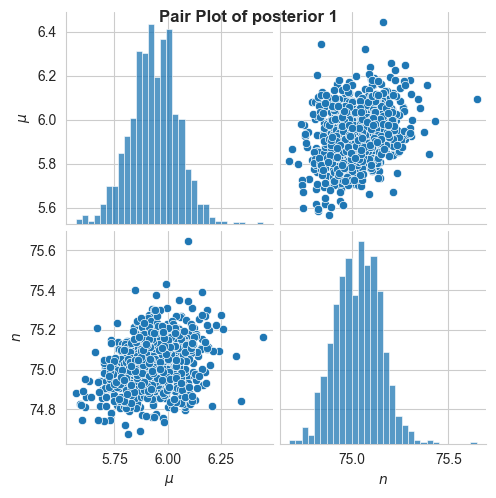

In [22]:
df1 = pd.DataFrame(theta_trained1_numpy, columns=[r"$\mu$", r"$n$"])
sns.pairplot(df1)
plt.suptitle('Pair Plot of posterior 1', fontsize=12, fontweight='bold')
plt.show()

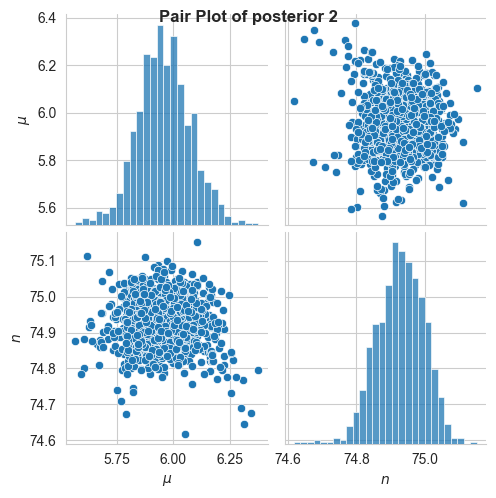

In [23]:
df2 = pd.DataFrame(theta_trained2_numpy, columns=[r"$\mu$", r"$n$"])
sns.pairplot(df2)
plt.suptitle('Pair Plot of posterior 2', fontsize=12, fontweight='bold')
plt.show()

### Observations outside the data space

In [24]:
torch.manual_seed(1)
np.random.seed(1)
true_theta = torch.tensor([12.0, 75.0], device=torch_device)
x_o_2 = simulator_torch_2(true_theta)
x_o_1 = x_o_2[[0, 2]]
true_theta, x_o_1, x_o_2

(tensor([12., 75.]),
 tensor([11.9354, 75.0000]),
 tensor([ 11.9354, 143.2808,  75.0000]))

In [25]:
theta_trained1 = posterior_1.set_default_x(x_o_1).sample((num_posterior_samples,), x=x_o_1)
theta_trained1 = theta_trained1.reshape((num_posterior_samples, 2))
theta_trained1_numpy = theta_trained1.cpu().numpy()

theta_trained2 = posterior_2.set_default_x(x_o_2).sample((num_posterior_samples,), x=x_o_2)
theta_trained2 = theta_trained2.reshape((num_posterior_samples, 2))
theta_trained2_numpy = theta_trained2.cpu().numpy()

  0%|          | 0/1000 [00:00<?, ?it/s]WARNING:root:Only 0.027% proposal samples are
                    accepted. It may take a long time to collect the remaining
                    997 samples. Consider interrupting (Ctrl-C) and switching to
                    `build_posterior(..., sample_with='mcmc')`.
1001it [00:24, 40.38it/s]                         
  0%|          | 0/1000 [00:00<?, ?it/s]WARNING:root:Only 0.009% proposal samples are
                    accepted. It may take a long time to collect the remaining
                    999 samples. Consider interrupting (Ctrl-C) and switching to
                    `build_posterior(..., sample_with='mcmc')`.
  8%|▊         | 81/1000 [00:02<00:23, 39.27it/s]

KeyboardInterrupt: 

  8%|▊         | 82/1000 [00:13<00:23, 39.27it/s]

In [26]:
torch.manual_seed(1)
np.random.seed(1)
true_theta = torch.tensor([5.0, 250.0], device=torch_device)
x_o_2 = simulator_torch_2(true_theta)
x_o_1 = x_o_2[[0, 2]]
true_theta, x_o_1, x_o_2

(tensor([  5., 250.]),
 tensor([  5.0645, 250.0000]),
 tensor([  5.0645,  26.7496, 250.0000]))

In [27]:
theta_trained1 = posterior_1.set_default_x(x_o_1).sample((num_posterior_samples,), x=x_o_1)
theta_trained1 = theta_trained1.reshape((num_posterior_samples, 2))
theta_trained1_numpy = theta_trained1.cpu().numpy()

theta_trained2 = posterior_2.set_default_x(x_o_2).sample((num_posterior_samples,), x=x_o_2)
theta_trained2 = theta_trained2.reshape((num_posterior_samples, 2))
theta_trained2_numpy = theta_trained2.cpu().numpy()

                    accepted. It may take a long time to collect the remaining
                    1000 samples. Consider interrupting (Ctrl-C) and switching to
                    `build_posterior(..., sample_with='mcmc')`.


KeyboardInterrupt: 

### Posterior distribution of $\mu$ that changes by $n$.

In [32]:
n_list = [25.0, 100.0, 150.0]

prior_a = 0.0
prior_b = 10.0
theta_grid = np.linspace(0, 10, 1000)
x_o_1_numpy = x_o_1.cpu().numpy()

prior_d = uniform.pdf(theta_grid, loc=prior_a, scale=(prior_b - prior_a))

true_posterior_list = []
npe_posterior_list = []
for i in range(len(n_list)):
    x_o_1_numpy[1] = n_list[i]
    x_o_1[1] = n_list[i]

    likelihood = norm.pdf(x_o_1_numpy[0], loc=theta_grid, scale=1/np.sqrt(x_o_1_numpy[1]))
    unnormalized_posterior = likelihood * prior_d
    d_theta = theta_grid[1] - theta_grid[0]
    posterior = unnormalized_posterior / (np.sum(unnormalized_posterior) * d_theta)
    true_posterior_list.append(posterior)

    theta_trained1 = posterior_1.set_default_x(x_o_1).sample((num_posterior_samples,), x=x_o_1)
    theta_trained1 = theta_trained1.reshape((num_posterior_samples, 2))
    theta_trained1_numpy = theta_trained1.cpu().numpy()
    npe_posterior_list.append(theta_trained1_numpy)


100%|██████████| 1000/1000 [00:00<00:00, 64548.61it/s]

100%|██████████| 1000/1000 [00:00<00:00, 63959.01it/s]

100%|██████████| 1000/1000 [00:00<00:00, 64048.87it/s]


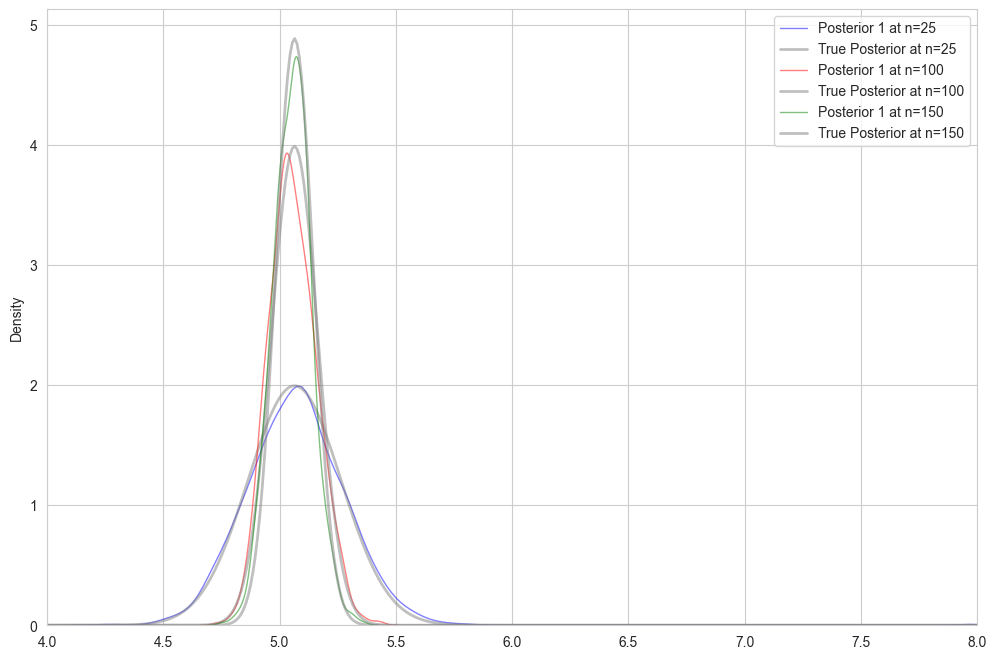

In [33]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(npe_posterior_list[0][:, 0], label='Posterior 1 at n=25', color='blue', linewidth=1, alpha=0.5)
plt.plot(theta_grid, true_posterior_list[0], label='True Posterior at n=25', color='gray', linewidth=2, alpha=0.5)
sns.kdeplot(npe_posterior_list[1][:, 0], label='Posterior 1 at n=100', color='red', linewidth=1, alpha=0.5)
plt.plot(theta_grid, true_posterior_list[1], label='True Posterior at n=100', color='gray', linewidth=2, alpha=0.5)
sns.kdeplot(npe_posterior_list[2][:, 0], label='Posterior 1 at n=150', color='green', linewidth=1, alpha=0.5)
plt.plot(theta_grid, true_posterior_list[2], label='True Posterior at n=150', color='gray', linewidth=2, alpha=0.5)
plt.xlim(4, 8)
plt.legend()
plt.show()

In [34]:
n_list = [25.0, 100.0, 150.0]

prior_a = 0.0
prior_b = 10.0
theta_grid = np.linspace(0, 10, 1000)

prior_d = uniform.pdf(theta_grid, loc=prior_a, scale=(prior_b - prior_a))

true_posterior_list = []
npe_posterior_list = []
for i in range(len(n_list)):
    true_theta = torch.tensor([6.0, n_list[i]], device=torch_device)
    x_o_2 = simulator_torch_2(true_theta)
    x_o_2_numpy = x_o_2.cpu().numpy()

    likelihood = norm.pdf(x_o_2_numpy[0], loc=theta_grid, scale=1/np.sqrt(x_o_2_numpy[2]))
    unnormalized_posterior = likelihood * prior_d
    d_theta = theta_grid[1] - theta_grid[0]
    posterior = unnormalized_posterior / (np.sum(unnormalized_posterior) * d_theta)
    true_posterior_list.append(posterior)

    theta_trained2 = posterior_2.set_default_x(x_o_2).sample((num_posterior_samples,), x=x_o_2)
    theta_trained2 = theta_trained2.reshape((num_posterior_samples, 2))
    theta_trained2_numpy = theta_trained2.cpu().numpy()
    npe_posterior_list.append(theta_trained2_numpy)


100%|██████████| 1000/1000 [00:00<00:00, 38405.86it/s]

100%|██████████| 1000/1000 [00:00<00:00, 134222.02it/s]

100%|██████████| 1000/1000 [00:00<00:00, 63984.38it/s]


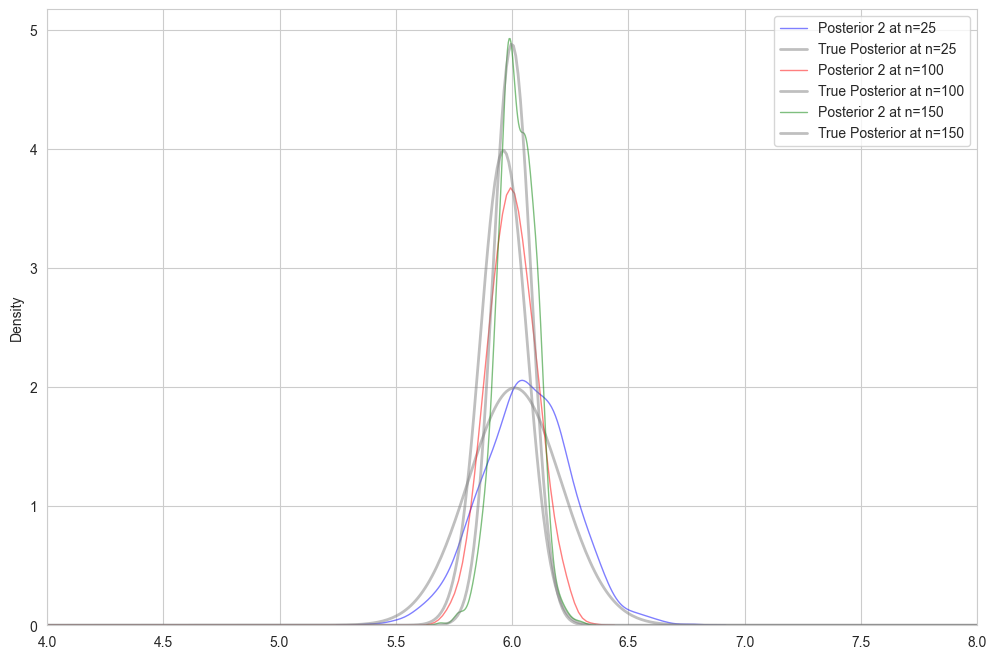

In [35]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(npe_posterior_list[0][:, 0], label='Posterior 2 at n=25', color='blue', linewidth=1, alpha=0.5)
plt.plot(theta_grid, true_posterior_list[0], label='True Posterior at n=25', color='gray', linewidth=2, alpha=0.5)
sns.kdeplot(npe_posterior_list[1][:, 0], label='Posterior 2 at n=100', color='red', linewidth=1, alpha=0.5)
plt.plot(theta_grid, true_posterior_list[1], label='True Posterior at n=100', color='gray', linewidth=2, alpha=0.5)
sns.kdeplot(npe_posterior_list[2][:, 0], label='Posterior 2 at n=150', color='green', linewidth=1, alpha=0.5)
plt.plot(theta_grid, true_posterior_list[2], label='True Posterior at n=150', color='gray', linewidth=2, alpha=0.5)
plt.xlim(4, 8)
plt.legend()
plt.show()

### Summary network

In [40]:
def simulator_torch_3(theta):
    x = torch.randn(theta[1].int(), device=torch_device) + theta[0]
    s3 = torch.tensor([torch.mean(x),
                       torch.mean(x**2),
                       torch.mean(x**3),
                       torch.mean(x**4),
                       torch.mean(x**5),
                       torch.mean(x**6),
                       torch.mean(x**7),
                       torch.mean(x**8),
                       torch.mean(x**9),
                       torch.mean(x**10),
                       theta[1]], device=torch_device)
    return s3

In [43]:
simulator = simulator_torch_3

prior, num_parameters, prior_returns_numpy = process_prior(prior_torch)
simulator = process_simulator(simulator, prior, prior_returns_numpy)
check_sbi_inputs(simulator, prior)

learning_rate = 0.0005  # default value

torch.manual_seed(seed)
np.random.seed(seed)

theta, x_3 = simulate_for_sbi(
    simulator=simulator, proposal=prior, num_simulations=simulation_budget
)

100%|██████████| 50000/50000 [00:07<00:00, 6655.57it/s]


In [48]:
def run_npe2(prior, theta, x, seed=1, num_epochs=500):
    torch.manual_seed(seed)
    np.random.seed(seed)
    learning_rate = 0.0005  # default value

    embedding_net = FCEmbedding(
        input_dim=11, 
        output_dim=3, 
        num_hiddens=15, 
        num_layers=2
    )

    neural_posterior = posterior_nn(
        model="nsf", 
        embedding_net=embedding_net 
    )

    inference = NPE_C(prior=prior, density_estimator=neural_posterior, device=torch_device)

    density_estimator = inference.append_simulations(theta, x).train(
        max_num_epochs=num_epochs, 
        learning_rate=learning_rate,
        stop_after_epochs=20
    )

    fig, axes = plot_summary(
        inference, 
        tags=["training_loss", "validation_loss"], 
        figsize=(8, 4)
    )
    plt.title("Training and Validation Loss")
    plt.show()

    return inference.build_posterior(density_estimator)

 Training neural network. Epochs trained: 64

 Neural network successfully converged after 65 epochs.

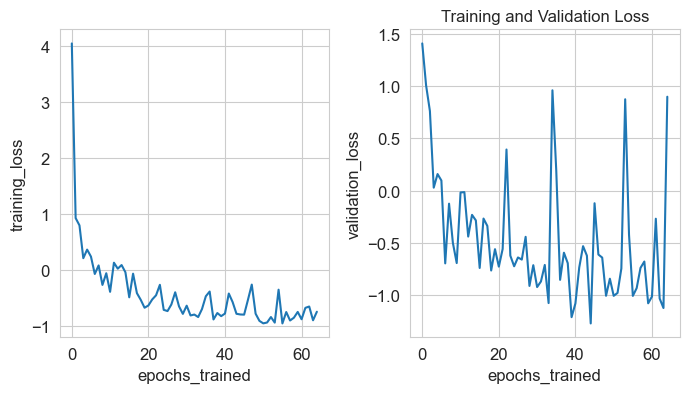

In [46]:
posterior_3 = run_npe(prior, theta, x_3)

 Training neural network. Epochs trained: 3

  2%|▏         | 15/1000 [33:58<37:11:26, 135.93s/it]


 Training neural network. Epochs trained: 61

 Neural network successfully converged after 62 epochs.

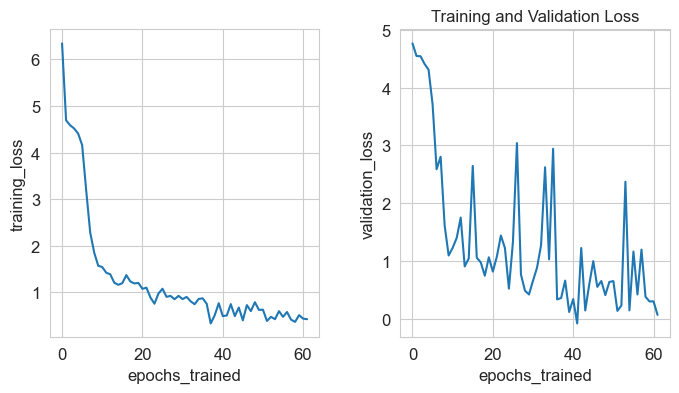

In [49]:
posterior_4 = run_npe2(prior, theta, x_3)

In [50]:
torch.manual_seed(1)
np.random.seed(1)
true_theta = torch.tensor([6.0, 75.0], device=torch_device)
x_o_3 = simulator_torch_3(true_theta)
true_theta, x_o_3

(tensor([ 6., 75.]),
 tensor([5.9354e+00, 3.6056e+01, 2.2407e+02, 1.4238e+03, 9.2443e+03, 6.1292e+04,
         4.1463e+05, 2.8591e+06, 2.0072e+07, 1.4330e+08, 7.5000e+01]))

In [52]:
theta_trained3 = posterior_3.set_default_x(x_o_3).sample((num_posterior_samples,), x=x_o_3)
theta_trained3 = theta_trained3.reshape((num_posterior_samples, 2))
theta_trained3_numpy = theta_trained3.cpu().numpy()

theta_trained4 = posterior_4.set_default_x(x_o_3).sample((num_posterior_samples,), x=x_o_3)
theta_trained4 = theta_trained4.reshape((num_posterior_samples, 2))
theta_trained4_numpy = theta_trained4.cpu().numpy()

100%|██████████| 1000/1000 [00:00<00:00, 30270.45it/s]
1098it [00:00, 32135.78it/s]            


In [53]:
prior_a = 0.0
prior_b = 10.0
theta_grid = np.linspace(0, 10, 1000)
x_o_3_numpy = x_o_3.cpu().numpy()

prior_d = uniform.pdf(theta_grid, loc=prior_a, scale=(prior_b - prior_a))

likelihood = norm.pdf(x_o_3_numpy[0], loc=theta_grid, scale=1/np.sqrt(x_o_3_numpy[10]))

unnormalized_posterior = likelihood * prior_d
d_theta = theta_grid[1] - theta_grid[0]
posterior = unnormalized_posterior / (np.sum(unnormalized_posterior) * d_theta)

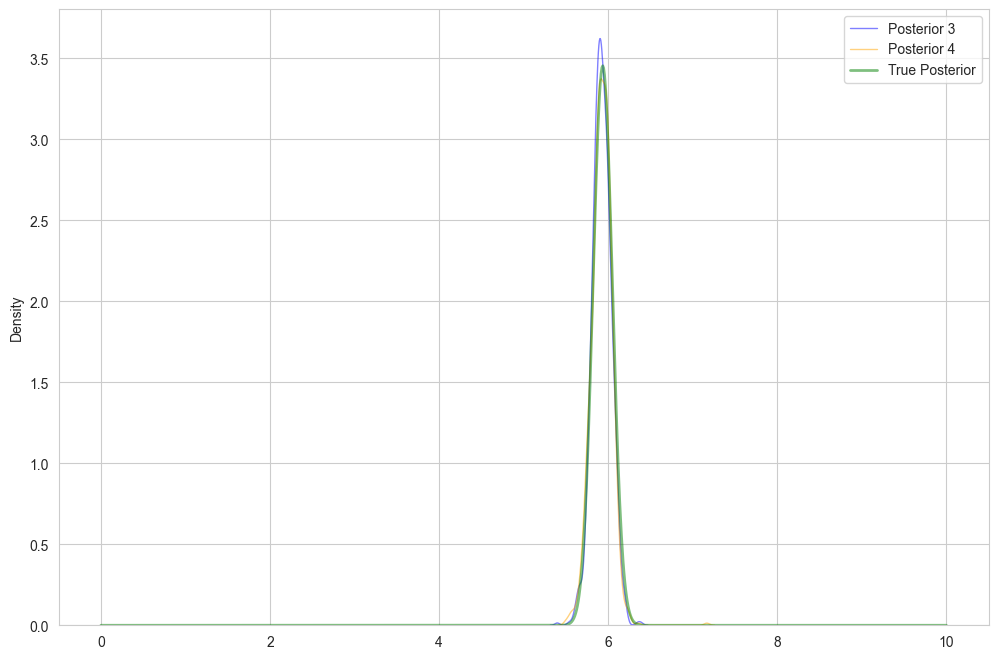

In [55]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained3_numpy[:, 0], label='Posterior 3', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained4_numpy[:, 0], label='Posterior 4', color='orange', linewidth=1, alpha=0.5)
plt.plot(theta_grid, posterior, label='True Posterior', color='green', linewidth=2, alpha=0.5)
plt.legend()
plt.show()

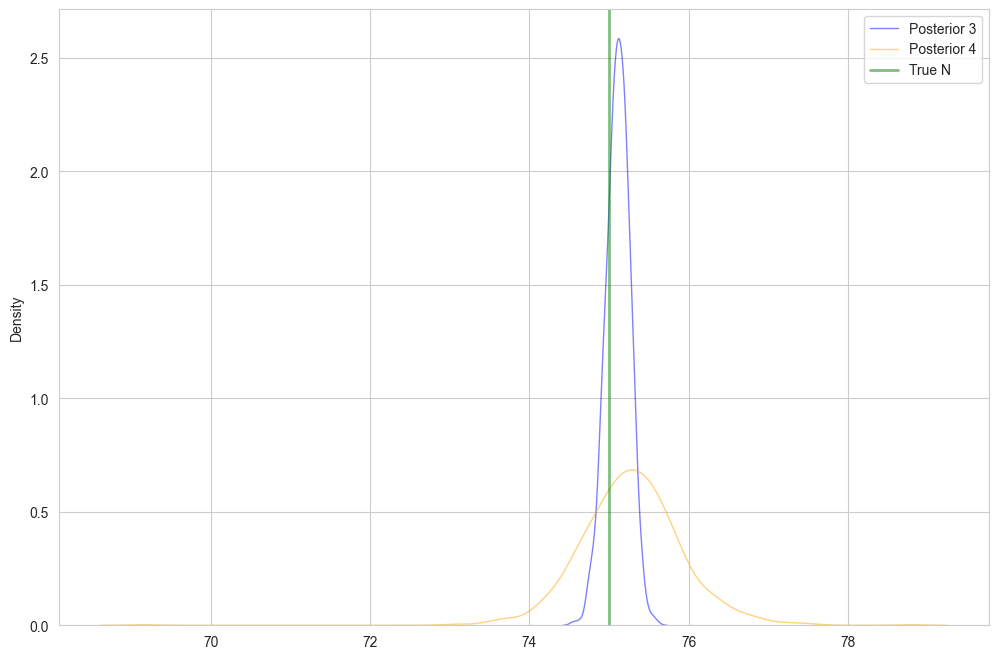

In [56]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained3_numpy[:, 1], label='Posterior 3', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained4_numpy[:, 1], label='Posterior 4', color='orange', linewidth=1, alpha=0.5)
plt.axvline(x=true_theta[1], label='True N', color='green', linewidth=2, alpha=0.5)
plt.legend()
plt.show()

## SBC

In [ ]:
simulators = [simulator_torch_1, simulator_torch_2, simulator_torch_3, simulator_torch_3]
posteriors = [posterior_1, posterior_2, posterior_3, posterior_4]

num_sbc_samples = 200
num_posterior_samples = 1000

sbc_results = []


--- Running SBC for Model 1 ---


Calculating ranks for 200 SBC samples: 100%|██████████| 200/200 [00:00<00:00, 12272.30it/s]


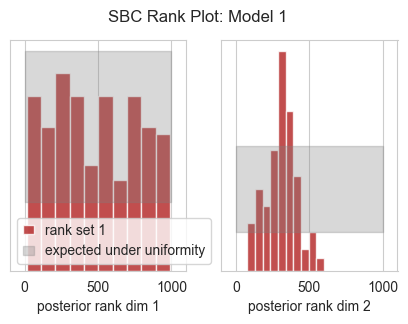


--- Running SBC for Model 2 ---


Calculating ranks for 200 SBC samples: 100%|██████████| 200/200 [00:00<00:00, 10393.90it/s]


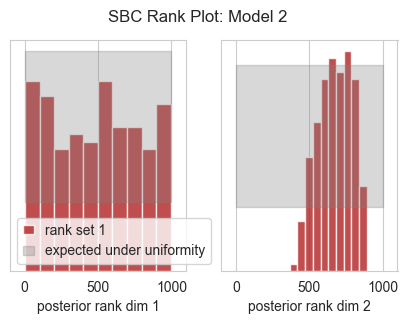


--- Running SBC for Model 3 ---


Calculating ranks for 200 SBC samples: 100%|██████████| 200/200 [00:00<?, ?it/s]


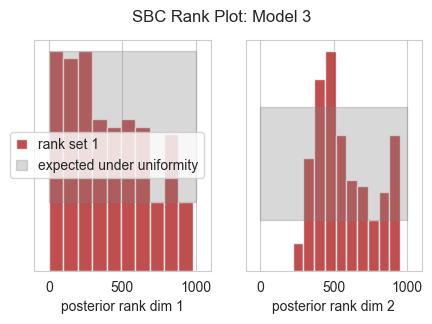


--- Running SBC for Model 4 ---


Calculating ranks for 200 SBC samples: 100%|██████████| 200/200 [00:00<?, ?it/s]


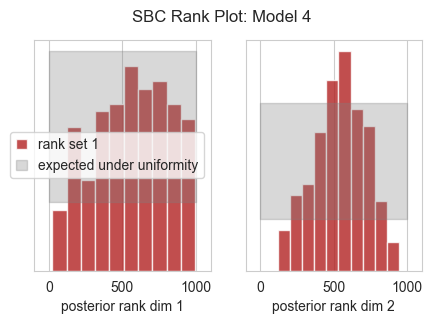

In [ ]:
for i, (sim, posterior) in enumerate(zip(simulators, posteriors)):
    print(f"\n--- Running SBC for Model {i+1} ---")

    theta_sbc = prior.sample((num_sbc_samples,))
    x_sbc = torch.stack([sim(t) for t in theta_sbc])

    ranks, dap_samples = run_sbc(
        theta_sbc, 
        x_sbc, 
        posterior, 
        num_posterior_samples=num_posterior_samples,
        use_batched_sampling=False
    )

    stats = check_sbc(
        ranks, 
        theta_sbc, 
        dap_samples, 
        num_posterior_samples=num_posterior_samples
    )
    
    sbc_results.append({
        "ranks": ranks, 
        "stats": stats
    })

    fig, ax = sbc_rank_plot(
        ranks, 
        num_posterior_samples, 
        plot_type="hist", 
        num_bins=10, 
        figsize=(5, 3)
    )
    
    fig.suptitle(f"SBC Rank Plot: Model {i+1}")
    plt.show()

## TARP

In [65]:
num_test_samples = 200
num_posterior_samples = 500

tarp_results = []

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\sbi\utils\diagnostics_utils.py:45: UserWarning: Capping max_sampling_batch_size from 10000 to 500 to avoid excessive memory usage.
  posterior_samples = posterior.sample_batched(



--- Running TARP for Model 1 ---


Drawing 500 samples for 200 observations: 505it [00:01, 261.65it/s]                         


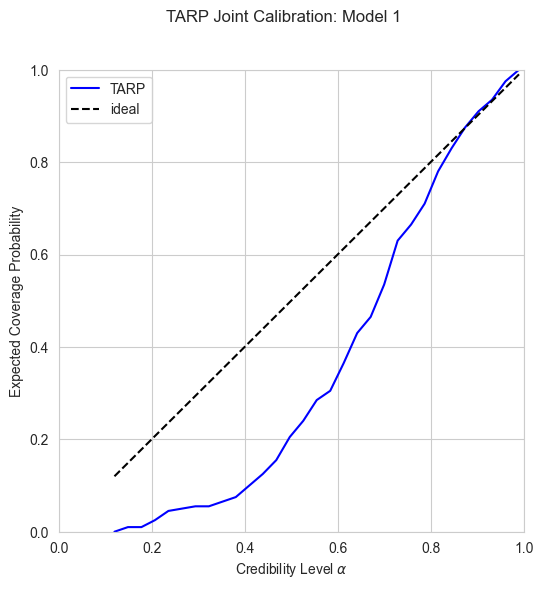


--- Running TARP for Model 2 ---


Drawing 500 samples for 200 observations: 567it [00:00, 832.34it/s]                         


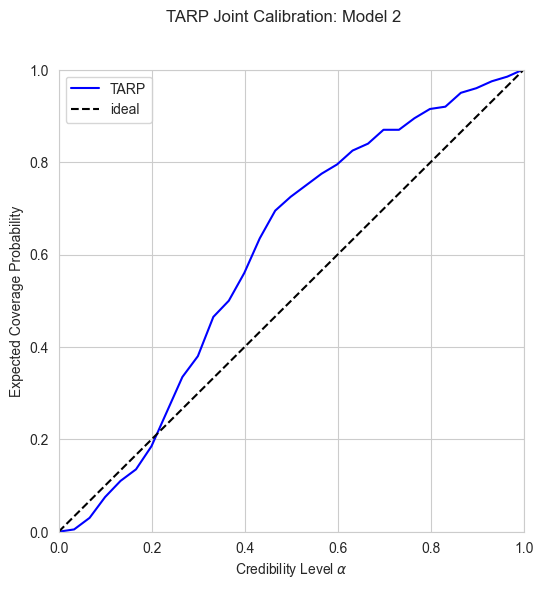


--- Running TARP for Model 3 ---


Drawing 500 samples for 200 observations: 520it [00:02, 223.18it/s]                         


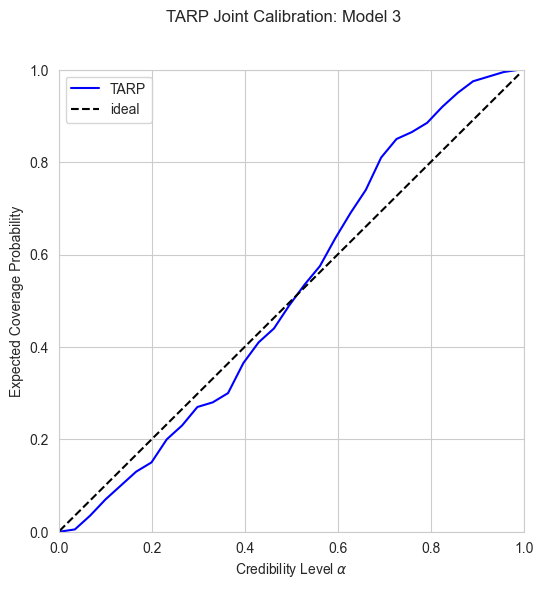


--- Running TARP for Model 4 ---


Drawing 500 samples for 200 observations: 584it [00:00, 606.59it/s]
  0%|          | 1/1000 [1:09:35<1158:38:43, 4175.30s/it]


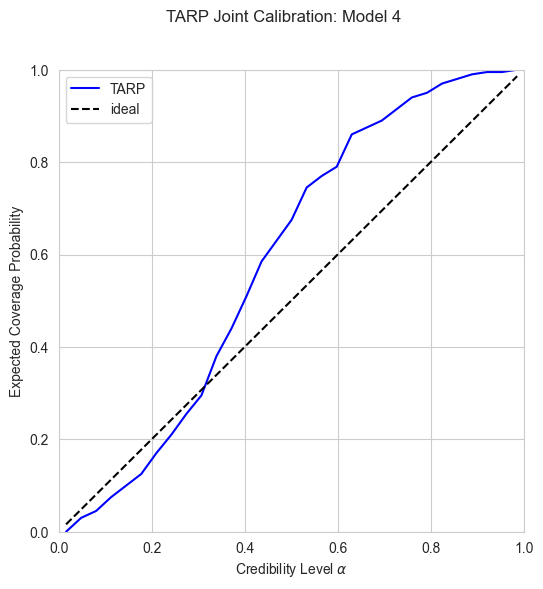

In [67]:
for i, (sim, posterior) in enumerate(zip(simulators, posteriors)):
    print(f"\n--- Running TARP for Model {i+1} ---")

    theta_test = prior.sample((num_test_samples,))
    x_test = torch.stack([sim(t) for t in theta_test])

    ecp, alpha = run_tarp(
        thetas=theta_test, 
        xs=x_test, 
        posterior=posterior, 
        num_posterior_samples=num_posterior_samples
    )
    
    tarp_results.append({
        "ecp": ecp,
        "alpha": alpha
    })

    fig, ax = plot_tarp(ecp, alpha)
    fig.suptitle(f"TARP Joint Calibration: Model {i+1}")
    plt.show()

In [ ]:
num_test_samples = 200
num_posterior_samples = 500

tarp_results = []


--- Running TARP for Model 1 ---


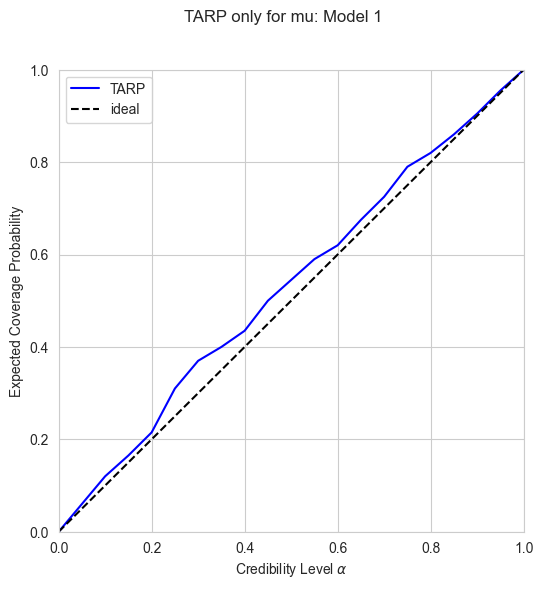


--- Running TARP for Model 2 ---


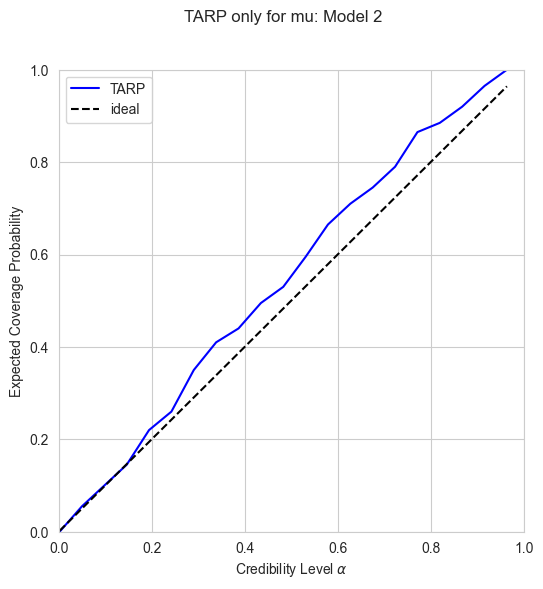


--- Running TARP for Model 3 ---


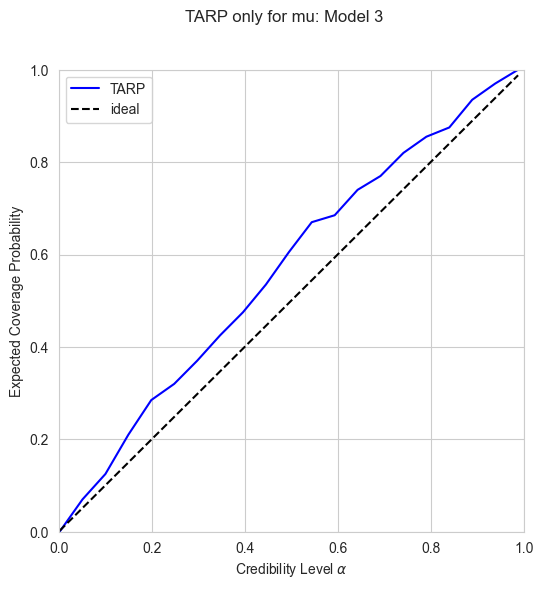


--- Running TARP for Model 4 ---


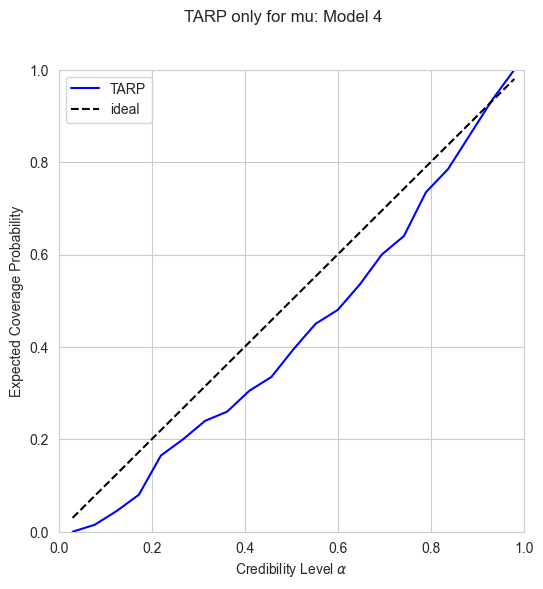

In [75]:
for i, (sim, posterior) in enumerate(zip(simulators, posteriors)):
    print(f"\n--- Running TARP for Model {i+1} ---")

    theta_test = prior.sample((num_test_samples,))
    x_test = torch.stack([sim(t) for t in theta_test])

    samples = []
    for x in x_test:
        samp = posterior.sample((num_posterior_samples,), x=x, show_progress_bars=False)
        samples.append(samp)
    samples = torch.stack(samples)

    dim_idx = 0
    samples_1d = samples[:, :, dim_idx:dim_idx+1].numpy() 
    theta_test_1d = theta_test[:, dim_idx:dim_idx+1].numpy()
    samples_1d = np.transpose(samples_1d, (1, 0, 2))

    ecp, alpha = tarp.get_tarp_coverage(
        samples_1d, 
        theta_test_1d, 
        references="random", 
        metric="euclidean"
    )
    
    tarp_results.append({
        "ecp": ecp,
        "alpha": alpha
    })

    fig, ax = plot_tarp(ecp, alpha)
    fig.suptitle(f"TARP only for mu: Model {i+1}")
    plt.show()